
## # 🎵 Spotify Data Analytics Capstone Project  
### Exploratory Data Analysis & Popularity Prediction using Python  

### **Prepared by:** Adarsh  

---

### 1. Introduction

The goal of this project is to analyze Spotify data to uncover:

- Music trends over time  
- Song characteristics (audio features)  
- User preferences (artists, genres, popularity)  
- Factors affecting song popularity  

We will follow these main steps (as per project brief):

1. **Introduction**  
2. **Data Collection and Preprocessing**  
3. **Data Analysis (EDA)**  
4. **Visualization**  
5. **Modeling and Predictions**  
6. **Conclusion**  
7. **Documentation-style explanation (this notebook)**  

#### We will use 5 CSV files:

- `data.csv` – Track-level data with audio features and popularity  
- `data_by_artist.csv` – Aggregated data by artist  
- `data_by_genres.csv` – Aggregated data by genre  
- `data_by_year.csv` – Aggregated data by release year  
- `data_w_genres.csv` – Track-level data with genre tags  

---



### 2. Import libraries

In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
from sklearn.tree import DecisionTreeRegressor

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

In [10]:
sns.set(style="whitegrid")

In [11]:
plt.rcParams['figure.figsize'] = (10, 5)

### 2. Data Collection and Preprocessing
#### We load all five datasets and get a basic understanding of their structure.


In [13]:
df_tracks = pd.read_csv('data.csv')

In [14]:
df_artist = pd.read_csv('data_by_artist.csv')


In [15]:
df_genres = pd.read_csv('data_by_genres.csv')

In [16]:
df_years = pd.read_csv('data_by_year.csv')

In [17]:
df_tracks_genres = pd.read_csv('data_w_genres.csv')

In [18]:
df_tracks.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.381,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.229,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665


In [19]:
print("Tracks shape:", df_tracks.shape)
print("By artist shape:", df_artist.shape)
print("By genres shape:", df_genres.shape)
print("By year shape:", df_years.shape)
print("Tracks with genres shape:", df_tracks_genres.shape)


Tracks shape: (170653, 19)
By artist shape: (28680, 15)
By genres shape: (2973, 14)
By year shape: (100, 14)
Tracks with genres shape: (28680, 16)


In [20]:
df_tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

In [21]:
df_tracks.isnull().sum()

valence             0
year                0
acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
explicit            0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
name                0
popularity          0
release_date        0
speechiness         0
tempo               0
dtype: int64

### **Observation:**  
- We check number of rows, columns, and missing values.  
- `data.csv` is our main track-level dataset and will be used for most EDA and modeling.  

---


#### ## 4. Data Preprocessing (Main Track Dataset: `data.csv`)

We will:

- Remove duplicate rows  
- Handle missing values for numeric and categorical features  
- Make sure data types are correct  


In [22]:
# Remove duplicates
df_tracks.drop_duplicates(inplace=True)


In [23]:
# Identify important numeric columns (may vary slightly based on actual data)
numeric_cols = [
    'valence', 'year', 'acousticness', 'danceability', 'duration_ms',
    'energy', 'instrumentalness', 'liveness', 'loudness',
    'speechiness', 'tempo', 'popularity'
]

for col in numeric_cols:
    if col in df_tracks.columns:
        df_tracks[col] = pd.to_numeric(df_tracks[col], errors='coerce')
        df_tracks[col] = df_tracks[col].fillna(df_tracks[col].median())


In [24]:
# Fill some text columns if present
for col in ['artists', 'name', 'release_date']:
    if col in df_tracks.columns:
        df_tracks[col] = df_tracks[col].fillna('Unknown')

df_tracks.isnull().sum()

valence             0
year                0
acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
explicit            0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
name                0
popularity          0
release_date        0
speechiness         0
tempo               0
dtype: int64

#### **Now the main dataset is cleaned enough for EDA and modeling.**  

---

## 5. Exploratory Data Analysis (EDA) – Main Tracks

### 5.1 Descriptive Statistics


In [25]:
df_tracks[numeric_cols].describe()

,valence,year,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,popularity
count,170653.000000,170653.000000,170653.000000,170653.000000,1.706530e+05,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000
mean,0.528587,1976.787241,0.502115,0.537396,2.309483e+05,0.482389,0.167010,0.205839,-11.467990,0.098393,116.861590,31.431794
std,0.263171,25.917853,0.376032,0.176138,1.261184e+05,0.267646,0.313475,0.174805,5.697943,0.162740,30.708533,21.826615
min,0.000000,1921.000000,0.000000,0.000000,5.108000e+03,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000
25%,0.317000,1956.000000,0.102000,0.415000,1.698270e+05,0.255000,0.000000,0.098800,-14.615000,0.034900,93.421000,11.000000
50%,0.540000,1977.000000,0.516000,0.548000,2.074670e+05,0.471000,0.000216,0.136000,-10.580000,0.045000,114.729000,33.000000
75%,0.747000,1999.000000,0.893000,0.668000,2.624000e+05,0.703000,0.102000,0.261000,-7.183000,0.075600,135.537000,48.000000
max,1.000000,2020.000000,0.996000,0.988000,5.403500e+06,1.000000,1.000000,1.000000,3.855000,0.970000,243.507000,100.000000


### 5.2 Distribution of Key Audio Features

We analyze how features like **danceability, energy, tempo, valence** are distributed.


In [26]:
plt.figure(figsize=(14, 10))

<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

Text(0.5, 1.0, 'Danceability Distribution')

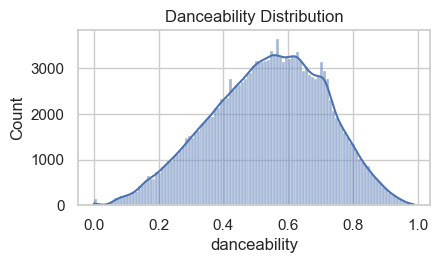

In [27]:
plt.subplot(2, 2, 1)
sns.histplot(df_tracks['danceability'], kde=True)
plt.title('Danceability Distribution')


Text(0.5, 1.0, 'Energy Distribution')

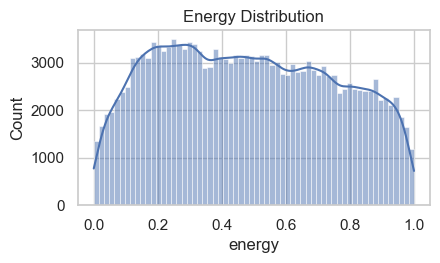

In [28]:
plt.subplot(2, 2, 2)
sns.histplot(df_tracks['energy'], kde=True)
plt.title('Energy Distribution')


Text(0.5, 1.0, 'Tempo Distribution')

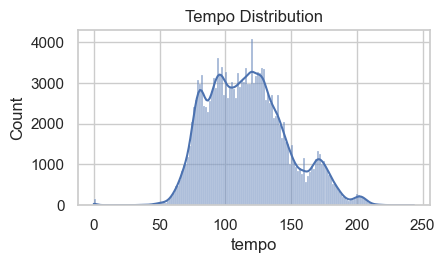

In [29]:
plt.subplot(2, 2, 3)
sns.histplot(df_tracks['tempo'], kde=True)
plt.title('Tempo Distribution')


Text(0.5, 1.0, 'Valence Distribution')

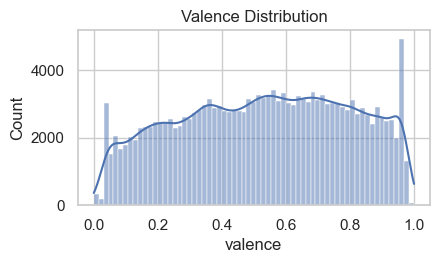

In [30]:
plt.subplot(2, 2, 4)
sns.histplot(df_tracks['valence'], kde=True)
plt.title('Valence Distribution')


In [32]:
plt.tight_layout()

<Figure size 1000x500 with 0 Axes>

In [ ]:
plt.show()

### ### 5.3 Popularity Distribution

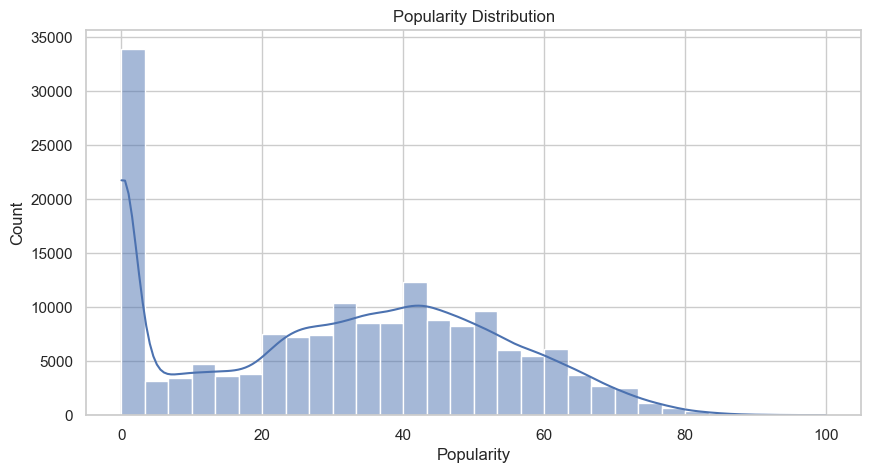

In [34]:
sns.histplot(df_tracks['popularity'], bins=30, kde=True)
plt.title('Popularity Distribution')
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.show()


#### **Insight Example:**  
- Most songs have a moderate popularity score, with fewer songs at extreme (very low or very high) popularity.  

---

## 6. Trends Over Time (Using `data_by_year.csv`)

Here we analyze how music features and popularity change over time.


In [35]:
df_years.head()

,mode,year,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,1921,0.886896,0.418597,260537.166667,0.231815,0.344878,0.205710,-17.048667,0.073662,101.531493,0.379327,0.653333,2
1,1,1922,0.938592,0.482042,165469.746479,0.237815,0.434195,0.240720,-19.275282,0.116655,100.884521,0.535549,0.140845,10
2,1,1923,0.957247,0.577341,177942.362162,0.262406,0.371733,0.227462,-14.129211,0.093949,114.010730,0.625492,5.389189,0
3,1,1924,0.940200,0.549894,191046.707627,0.344347,0.581701,0.235219,-14.231343,0.092089,120.689572,0.663725,0.661017,10
4,1,1925,0.962607,0.573863,184986.924460,0.278594,0.418297,0.237668,-14.146414,0.111918,115.521921,0.621929,2.604317,5


In [36]:
df_years.describe()

,mode,year,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
count,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.0000
mean,1.0,1970.500000,0.556317,0.536783,227296.752234,0.452705,0.193582,0.208224,-11.969054,0.105861,116.015674,0.532120,27.376065,3.7900
std,0.0,29.011492,0.275358,0.052356,25630.048065,0.161738,0.122488,0.017903,3.105610,0.082128,5.669645,0.057809,20.703197,3.5627
min,1.0,1921.000000,0.219931,0.414445,156881.657475,0.207948,0.016376,0.168450,-19.275282,0.049098,100.884521,0.379327,0.140845,0.0000
25%,1.0,1945.750000,0.289516,0.500800,210889.193536,0.280733,0.103323,0.197509,-14.189232,0.064244,111.718626,0.497174,3.298200,0.0000
50%,1.0,1970.500000,0.459190,0.540976,235520.850833,0.495997,0.127644,0.206074,-11.773061,0.085763,117.455548,0.541503,33.619250,2.0000
75%,1.0,1995.250000,0.856711,0.570948,247702.738058,0.598008,0.276707,0.218493,-9.950542,0.104438,120.606644,0.570080,44.943375,7.0000
max,1.0,2020.000000,0.962607,0.692904,267677.823086,0.681778,0.581701,0.264335,-6.595067,0.490001,124.283129,0.663725,65.256542,10.0000


### 6.1 Popularity Over Years


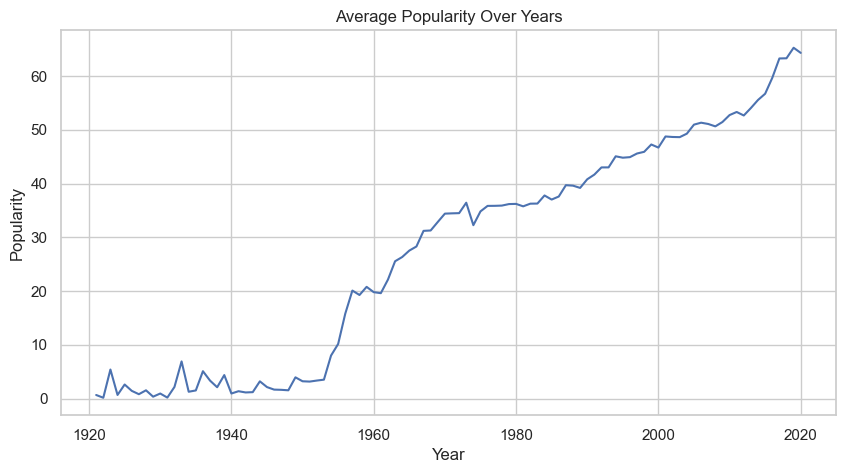

In [37]:
sns.lineplot(data=df_years, x='year', y='popularity')
plt.title('Average Popularity Over Years')
plt.xlabel('Year')
plt.ylabel('Popularity')
plt.show()


### 6.2 Danceability and Energy Over Years


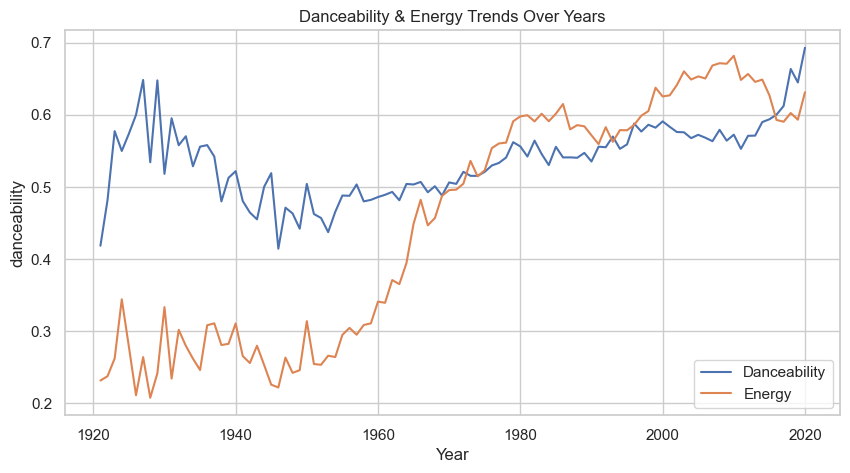

In [38]:
sns.lineplot(data=df_years, x='year', y='danceability', label='Danceability')
sns.lineplot(data=df_years, x='year', y='energy', label='Energy')
plt.title('Danceability & Energy Trends Over Years')
plt.xlabel('Year')
plt.legend()
plt.show()


### **Insight Ideas:**

- Are modern songs becoming more danceable or energetic compared to older songs?  
- Are there specific decades with clearly different feature profiles?  

---

## 7. Genre-wise Analysis (Using `data_by_genres.csv`)

We now analyze genres and their characteristics.


In [39]:
df_genres.head()


,mode,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,21st century classical,0.979333,0.162883,1.602977e+05,0.071317,0.606834,0.361600,-31.514333,0.040567,75.336500,0.103783,27.833333,6
1,1,432hz,0.494780,0.299333,1.048887e+06,0.450678,0.477762,0.131000,-16.854000,0.076817,120.285667,0.221750,52.500000,5
2,1,8-bit,0.762000,0.712000,1.151770e+05,0.818000,0.876000,0.126000,-9.180000,0.047000,133.444000,0.975000,48.000000,7
3,1,[],0.651417,0.529093,2.328809e+05,0.419146,0.205309,0.218696,-12.288965,0.107872,112.857352,0.513604,20.859882,7
4,1,a cappella,0.676557,0.538961,1.906285e+05,0.316434,0.003003,0.172254,-12.479387,0.082851,112.110362,0.448249,45.820071,7


### 7.1 Top Genres by Popularity


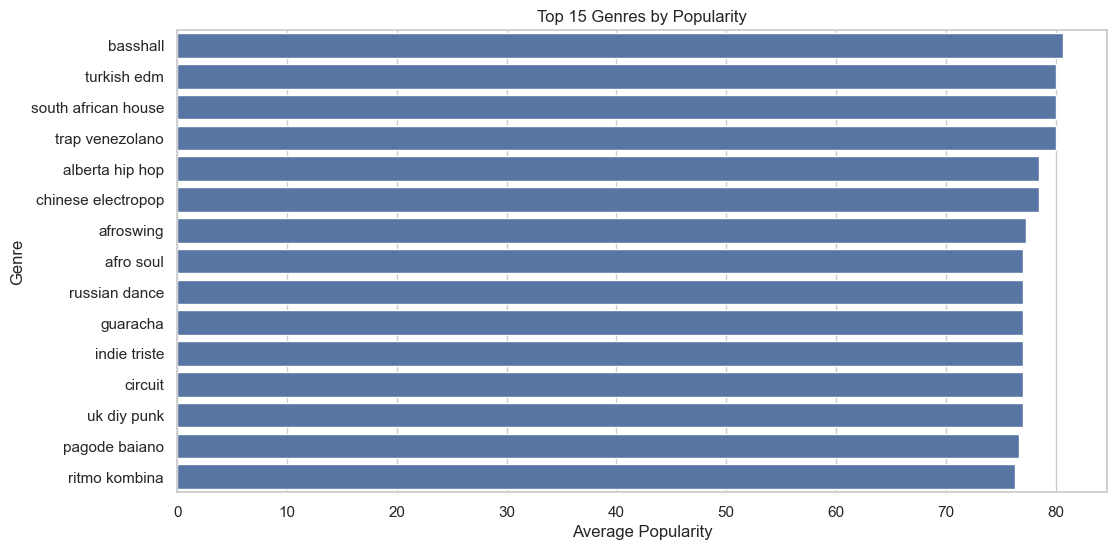

In [40]:
top_genres = df_genres.sort_values('popularity', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_genres, x='popularity', y='genres')
plt.title('Top 15 Genres by Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Genre')
plt.show()


### 7.2 Genres – Danceability vs Energy vs Popularity


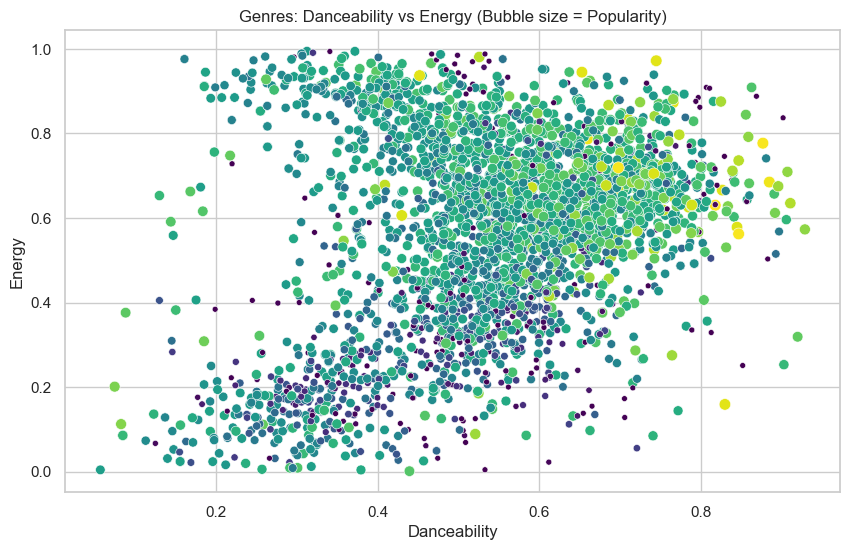

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_genres, x='danceability', y='energy',
    size='popularity', hue='popularity', palette='viridis', legend=False
)
plt.title('Genres: Danceability vs Energy (Bubble size = Popularity)')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.show()


### **Insight Ideas:**

- Genres with high danceability and high energy tend to be more popular.  
- Some genres may be more acoustic/low energy but still popular.  

---

## 8. User Preferences & Listening Habits (Using `data_by_artist.csv` and `data_w_genres.csv`)

We approximate user preferences using **artist-level statistics** and **track counts**.


In [42]:
df_artist.head()


,mode,count,acousticness,artists,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,9,0.590111,"""Cats"" 1981 Original London Cast",0.467222,250318.555556,0.394003,0.011400,0.290833,-14.448000,0.210389,117.518111,0.389500,38.333333,5
1,1,26,0.862538,"""Cats"" 1983 Broadway Cast",0.441731,287280.000000,0.406808,0.081158,0.315215,-10.690000,0.176212,103.044154,0.268865,30.576923,5
2,1,7,0.856571,"""Fiddler On The Roof” Motion Picture Chorus",0.348286,328920.000000,0.286571,0.024593,0.325786,-15.230714,0.118514,77.375857,0.354857,34.857143,0
3,1,27,0.884926,"""Fiddler On The Roof” Motion Picture Orchestra",0.425074,262890.962963,0.245770,0.073587,0.275481,-15.639370,0.123200,88.667630,0.372030,34.851852,0
4,1,7,0.510714,"""Joseph And The Amazing Technicolor Dreamcoat""...",0.467143,270436.142857,0.488286,0.009400,0.195000,-10.236714,0.098543,122.835857,0.482286,43.000000,5


### 8.1 Top Artists by Popularity


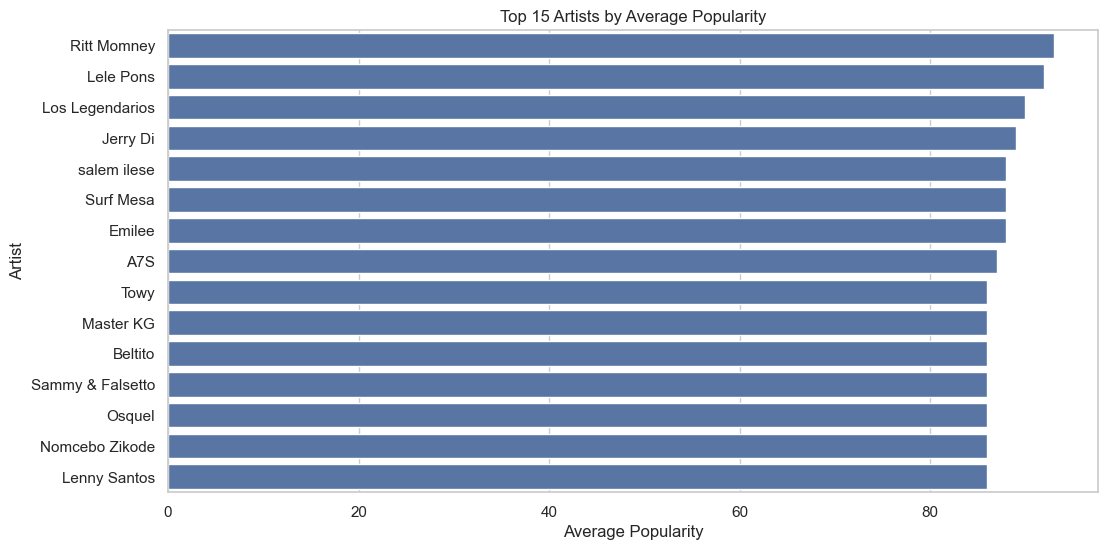

In [43]:
top_artists_pop = df_artist.sort_values('popularity', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_artists_pop, x='popularity', y='artists')
plt.title('Top 15 Artists by Average Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Artist')
plt.show()


#### if data_by_artist.csv` has a `count` or similar column (e.g., how often a track appears), we can find most frequently appearing artists.


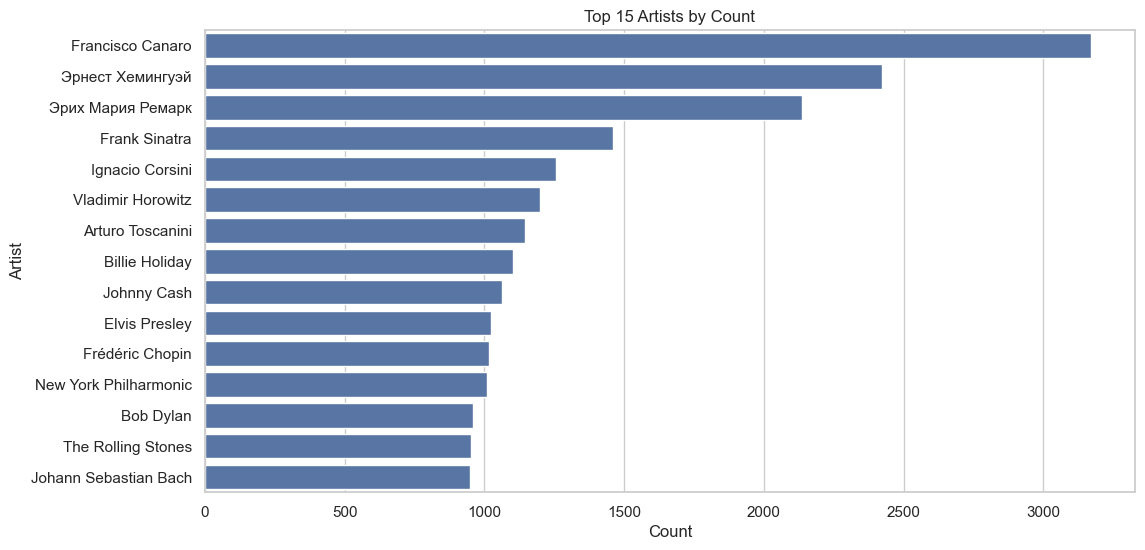

In [44]:
if 'count' in df_artist.columns:
    top_artists_count = df_artist.sort_values('count', ascending=False).head(15)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_artists_count, x='count', y='artists')
    plt.title('Top 15 Artists by Count')
    plt.xlabel('Count')
    plt.ylabel('Artist')
    plt.show()


### 8.2 Genre + Artist Combinations (Using `data_w_genres.csv`)


In [45]:
df_tracks_genres.head()

,genres,artists,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key,mode,count
0,['show tunes'],"""Cats"" 1981 Original London Cast",0.590111,0.467222,250318.555556,0.394003,0.011400,0.290833,-14.448000,0.210389,117.518111,0.389500,38.333333,5,1,9
1,[],"""Cats"" 1983 Broadway Cast",0.862538,0.441731,287280.000000,0.406808,0.081158,0.315215,-10.690000,0.176212,103.044154,0.268865,30.576923,5,1,26
2,[],"""Fiddler On The Roof” Motion Picture Chorus",0.856571,0.348286,328920.000000,0.286571,0.024593,0.325786,-15.230714,0.118514,77.375857,0.354857,34.857143,0,1,7
3,[],"""Fiddler On The Roof” Motion Picture Orchestra",0.884926,0.425074,262890.962963,0.245770,0.073587,0.275481,-15.639370,0.123200,88.667630,0.372030,34.851852,0,1,27
4,[],"""Joseph And The Amazing Technicolor Dreamcoat""...",0.510714,0.467143,270436.142857,0.488286,0.009400,0.195000,-10.236714,0.098543,122.835857,0.482286,43.000000,5,1,7


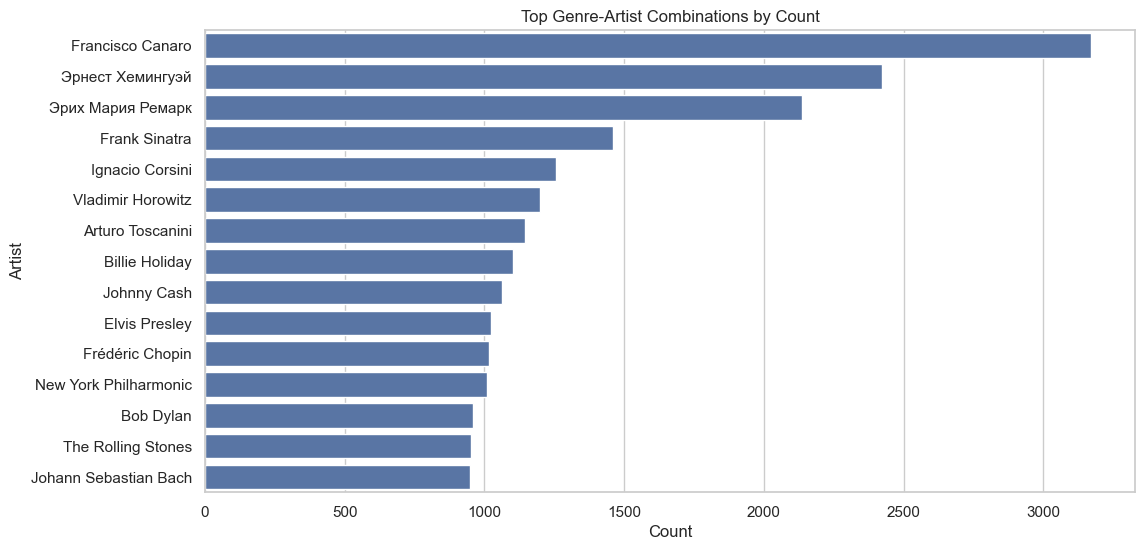

In [46]:
# If 'count' exists in data_w_genres, we can find top genre-artist combos
if 'count' in df_tracks_genres.columns:
    top_genre_artist = df_tracks_genres.sort_values('count', ascending=False).head(15)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_genre_artist, x='count', y='artists')
    plt.title('Top Genre-Artist Combinations by Count')
    plt.xlabel('Count')
    plt.ylabel('Artist')
    plt.show()


### **Insight Ideas:**

- Which artists dominate in terms of popularity or count?  
- Are there specific genre–artist combinations that have very high counts or popularity?  

---

## 9. Correlation Analysis (Main Tracks Dataset)

We examine correlation between audio features and popularity.


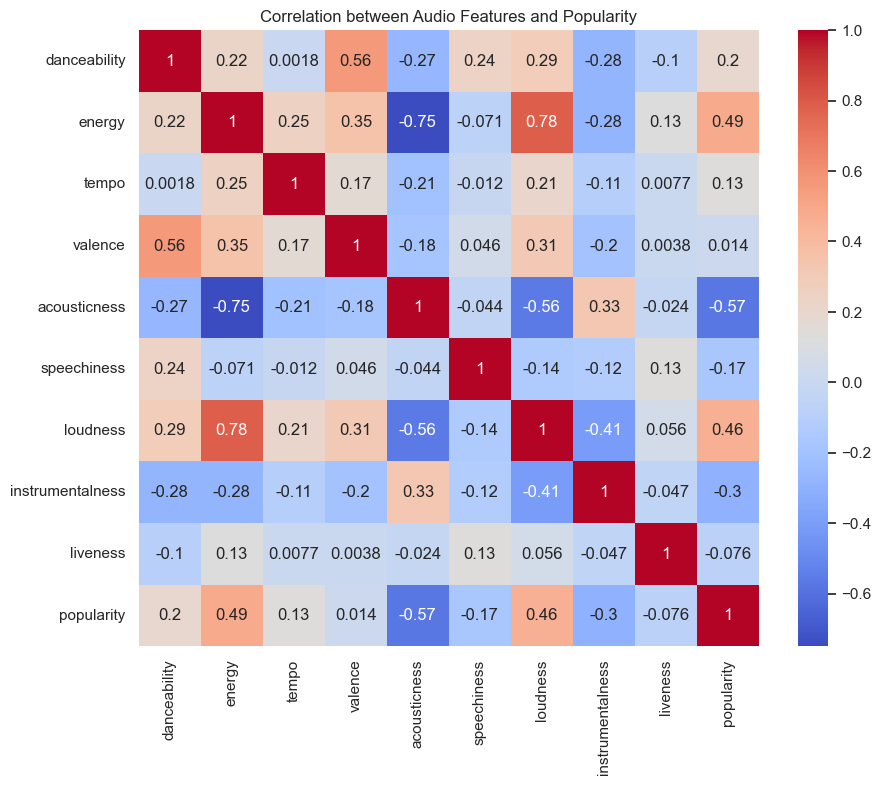

In [47]:
corr_cols = [
    'danceability', 'energy', 'tempo', 'valence', 'acousticness',
    'speechiness', 'loudness', 'instrumentalness', 'liveness', 'popularity'
]

corr_matrix = df_tracks[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation between Audio Features and Popularity')
plt.show()


### **Insight Ideas:**

- Does higher energy relate to higher popularity?  
- Is loudness negatively or positively correlated with popularity?  
- Are more danceable songs slightly more popular on average?  

---

## 10. Modeling and Predictions – Predicting Song Popularity

Now we try to build simple models to **predict popularity** using audio features.  
We will use:

#### - **Linear Regression**  
#### - **Decision Tree Regressor**  


In [48]:
feature_cols = [
    'danceability', 'energy', 'tempo', 'valence', 'acousticness',
    'speechiness', 'loudness', 'instrumentalness', 'liveness'
]

X = df_tracks[feature_cols]
y = df_tracks['popularity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((136522, 9), (34131, 9))

### 10.1 Linear Regression Model


In [49]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression MAE:", mae_lr)
print("Linear Regression R²:", r2_lr)


Linear Regression MAE: 13.11181674032174
Linear Regression R²: 0.4442210021178916


### 10.2 Decision Tree Regressor

In [50]:
dt_model = DecisionTreeRegressor(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree MAE:", mae_dt)
print("Decision Tree R²:", r2_dt)


Decision Tree MAE: 11.447003806504927
Decision Tree R²: 0.5292824577162089


## 10. Key Findings (Summary for Report)

You can write this part in your own words, but some example points:

- Spotify songs show clear patterns in audio features like danceability, energy, and valence.  
- Certain years show changes in average popularity and musical characteristics (e.g., more energetic / more danceable songs in recent years).  
- Some genres consistently have higher popularity and distinct feature profiles.  
- Popular artists and genre–artist combinations stand out when analyzing counts and popularity.  
- Audio features alone can partially predict popularity, but not perfectly (R² < 1.0), showing that other factors (marketing, artists, playlists, etc.) also matter.  

---

## 11. Conclusion

In this project, we:

- Loaded and cleaned multiple Spotify datasets (track, artist, genre, year, and genre-tagged tracks).  
- Performed exploratory data analysis to understand distributions, trends, and correlations.  
- Visualized key patterns in music trends, genres, and user preferences.  
- Built simple predictive models (Linear Regression & Decision Tree) to forecast song popularity based on audio features.  

This capstone connects **data analytics** with **real-world music data** and demonstrates how Python can be used for:

- Data preprocessing  
- EDA & visualization  
- Basic machine learning modeling  

For future work, we could:

- Try more advanced models (Random Forest, XGBoost, Neural Networks).  
- Include playlist/user-level data for better personalization.  
- Build a recommendation engine based on feature similarity.  

---

## Spotify Data Analytics – Capstone Project
##### Prepared by: Adarsh
##### Tools Used: Python (Pandas, NumPy, Matplotlib, Seaborn, Scikit‑Learn)


### 1. Objective
Analyze Spotify datasets to uncover:
- Music trends over time
- Genre & artist patterns
- Audio feature relationships
- Factors influencing song popularity
- Predictive modeling for popularity


### 2. Dataset Description
We used 5 datasets:
- data.csv – Track‑level audio features + popularity
- data_by_artist.csv – Artist‑level aggregated metrics
- data_by_genres.csv – Genre‑level audio features
- data_by_year.csv – Year‑wise music trends
- data_w_genres.csv – Track‑level data with genre tags
Total features analyzed: danceability, energy, valence, tempo, loudness, acousticness, speechiness, instrumentalness, liveness, popularity, etc.


### 3. Data Preprocessing
- Removed duplicates
- Handled missing values using median imputation
- Converted numeric columns
- Cleaned text fields (artists, names, release_date)
- Ensured consistent formatting across datasets


### 4. Exploratory Data Analysis (EDA)
#### Track‑level insights:
- Popularity distribution
- Feature distributions (danceability, energy, tempo, valence)
- Correlation heatmap
#### Year‑level insights:
- Popularity trend over decades
- Danceability & energy evolution
#### Genre‑level insights:
- Top genres by popularity
- Genre clusters based on energy & danceability
#### Artist‑level insights:
- Most popular artists
- Artists with highest play counts



### 5. Modeling & Predictions
Models used:
- Linear Regression
- Decision Tree Regressor
##### Metrics:
- MAE (Mean Absolute Error)
- R² Score
##### Outcome:
- Decision Tree performed better for non‑linear relationships
- Audio features moderately predict popularity




### 6. Conclusion
- Modern songs show higher energy & danceability
- Certain genres consistently dominate popularity
- Popularity depends on multiple audio features
- Predictive models show promising results but can be improved




### 7. Future Work
- Use Random Forest / XGBoost
- Build a recommendation system
- Add playlist/user-level data